# Broadband qubit spectroscopy

In [1]:
from pathlib import Path

from qblox_lab.config.device import save_device_configuration
from qblox_lab.config.hardware import create_hardware_agent
from qblox_lab.experiments.cal06_qubit_spectroscopy_full_bandwidth import BroadbandQubitSpectroscopy

## Run parameters

In [9]:
HARDWARE_CONFIG = Path(r"..\config\hw_config.json")
DEVICE_CONFIG = Path(r"..\config\dut_config.json")
FLUX_CONFIG = Path(r"..\config\flux_config.json")  # If use None, it will not change the value already in the hardware
OUTPUT_DIR = Path("data")

QUBITS = ["q0"]
FREQUENCY_CENTER = 5.4e9
FREQUENCY_WIDTH = 1.6e9
FREQUENCY_POINTS = 1001
MAXIMUM_BRANCH_WIDTH = 800e6
REPETITIONS = 10
DRIVE_AMPLITUDE = 0.02
DRIVE_DURATION = 1e-6

READOUT_AMPLITUDE = None
DRIVE_OUTPUT_ATTENUATION = None
READOUT_OUTPUT_ATTENUATION = None
READOUT_INPUT_ATTENUATION = None
RESTORE_DRIVE_LO_FREQUENCY = None
TIMEOUT = 300
CREATE_DUMMY_CONNECTIONS = False

PLOT_RESULTS = True
SAVE_FITTED_DEVICE = Path(r"..\config\dut_config_upd.json")  # Use None if param persisting is not required


## Hardware and experiment

In [3]:
hardware_agent = create_hardware_agent(
    hardware_configuration=HARDWARE_CONFIG,
    device_configuration=DEVICE_CONFIG,
    output_dir=OUTPUT_DIR,
    create_dummy_connections=CREATE_DUMMY_CONNECTIONS,
)

experiment = BroadbandQubitSpectroscopy(
    hardware_agent=hardware_agent,
    qubits=QUBITS,
    flux_config=FLUX_CONFIG,
)

## Branch plan

In [4]:
branches = experiment.plan_branches(
    frequency_center=FREQUENCY_CENTER,
    frequency_width=FREQUENCY_WIDTH,
    frequency_points=FREQUENCY_POINTS,
    maximum_branch_width=MAXIMUM_BRANCH_WIDTH,
)
for branch in branches:
    print(
        f"Branch {branch.index + 1}: "
        f"{branch.start / 1e9:.6f}-{branch.stop / 1e9:.6f} GHz, "
        f"LO {branch.lo_frequency / 1e9:.6f} GHz, "
        f"{branch.points} points"
    )

Branch 1: 4.600000-5.400000 GHz, LO 5.000000 GHz, 11 points
Branch 2: 5.480000-6.200000 GHz, LO 5.840000 GHz, 10 points


## Measurement

In [ ]:

dataset = experiment.run_measurement(
    frequency_center=FREQUENCY_CENTER,
    frequency_width=FREQUENCY_WIDTH,
    frequency_points=FREQUENCY_POINTS,
    maximum_branch_width=MAXIMUM_BRANCH_WIDTH,
    repetitions=REPETITIONS,
    drive_amplitude=DRIVE_AMPLITUDE,
    drive_duration=DRIVE_DURATION,
    readout_amplitude=READOUT_AMPLITUDE,
    drive_output_attenuation=DRIVE_OUTPUT_ATTENUATION,
    readout_output_attenuation=READOUT_OUTPUT_ATTENUATION,
    readout_input_attenuation=READOUT_INPUT_ATTENUATION,
    restore_drive_lo_frequency=RESTORE_DRIVE_LO_FREQUENCY,
    timeout=TIMEOUT,
)
dataset

c:\Users\yi.huang\anaconda3\envs\QSE\lib\site-packages\qblox_scheduler\backends\qblox\compiler_abc.py:285: UserWarning: Exact capabilities for ISA version 2.1 not found, using capabilities for version 2.2.
  warnings.warn(


## Optional: Simulated data

In [10]:
SIMULATED_QUBIT_FREQUENCY = None
SIMULATED_LINEWIDTH = 10e6
SIMULATED_BASELINE = 1.0
SIMULATED_CONTRAST = 0.2
SIMULATED_PHASE_OFFSET = 0.0
SIMULATED_NOISE = 0.002
SIMULATION_SEED = 42

In [11]:
dataset = experiment.simulated_data(
    frequency_center=FREQUENCY_CENTER,
    frequency_width=FREQUENCY_WIDTH,
    frequency_points=FREQUENCY_POINTS,
    qubit_frequency=SIMULATED_QUBIT_FREQUENCY,
    linewidth=SIMULATED_LINEWIDTH,
    baseline=SIMULATED_BASELINE,
    contrast=SIMULATED_CONTRAST,
    phase_offset=SIMULATED_PHASE_OFFSET,
    noise=SIMULATED_NOISE,
    seed=SIMULATION_SEED,
)

## Analysis

In [12]:
results = experiment.analysis()
for qubit, result in results.items():
    if result.success:
        print(
            f"{qubit}: f01 = {result.frequency / 1e9:.9f} GHz, "
            f"linewidth = {result.linewidth / 1e6:.3f} MHz"
        )
    else:
        print(f"{qubit}: qubit-spectroscopy fit failed")

q0: f01 = 5.444303044 GHz, linewidth = 10.007 MHz


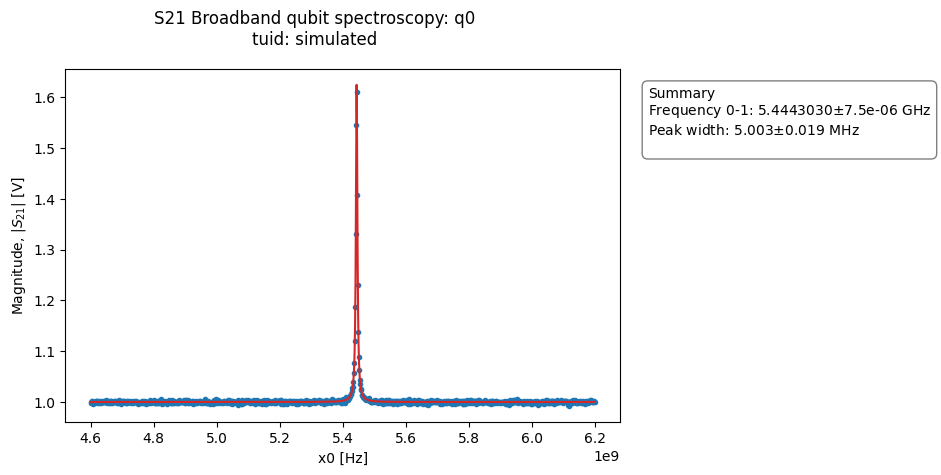

In [13]:
if PLOT_RESULTS:
    experiment.plot()

## Optional: device update

A successful fitted `f01` is written only to the new file selected by `SAVE_FITTED_DEVICE`. The input device file remains unchanged.

In [14]:
if SAVE_FITTED_DEVICE is not None:
    experiment.update_device()
    saved_path = save_device_configuration(
        hardware_agent.quantum_device,
        SAVE_FITTED_DEVICE,
    )
    print(f"Updated device configuration saved to {saved_path}")

Updated device configuration saved to ..\config\dut_config_upd.json
